In [18]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [20, 5]
# Set seed for reproducibility
# np.random.seed(1)
import pandas as pd
import sys
import os

#import inhouse ResComp
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "rescomp", "rescomp")))
import ResComp
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "utils")))
import file_io

### Parameter Initialization

In [19]:
# PARAMETERS FOR RESERVOIR
n = 200
erdos_c = 4
gamma = 10
sigma = 0.012
alpha = 0
p_thin = 0.7
rho = 0.5

mean_degree = erdos_c*(1-p_thin)
if mean_degree < 0.0:
    mean_degree = 0.0


#CONSTRUCTION OF RESERVOIR
rescomp = ResComp.ResComp(res_sz=n, mean_degree=mean_degree, 
                                ridge_alpha=alpha, spect_rad=rho, sigma=sigma, 
                                gamma=gamma, map_initial='activ_f')

### Getting Graph from the Resevoir Class

<class 'scipy.sparse._csr.csr_matrix'>


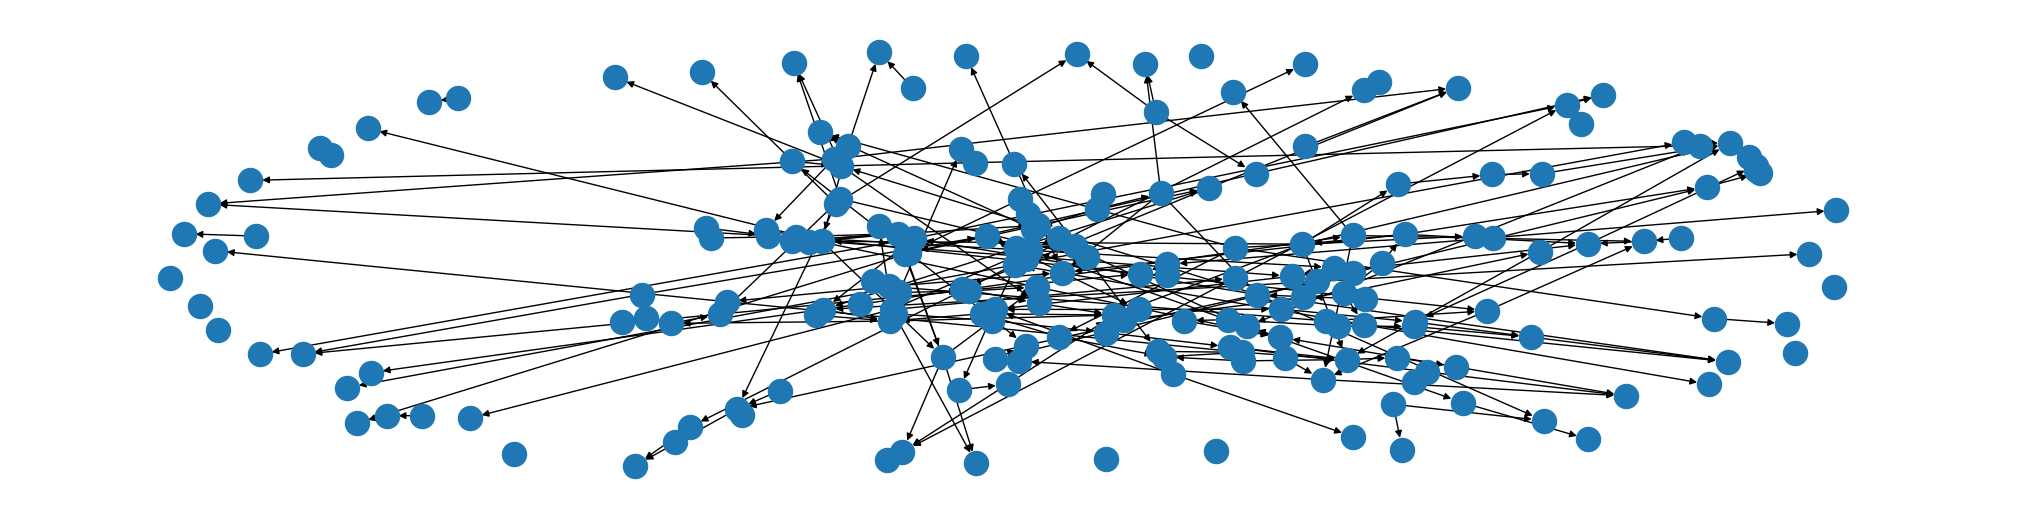

In [20]:
A = rescomp.res
print(type(A))
G = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
nx.draw(G)
plt.show()

### Getting the Degree Sequence (in/out)

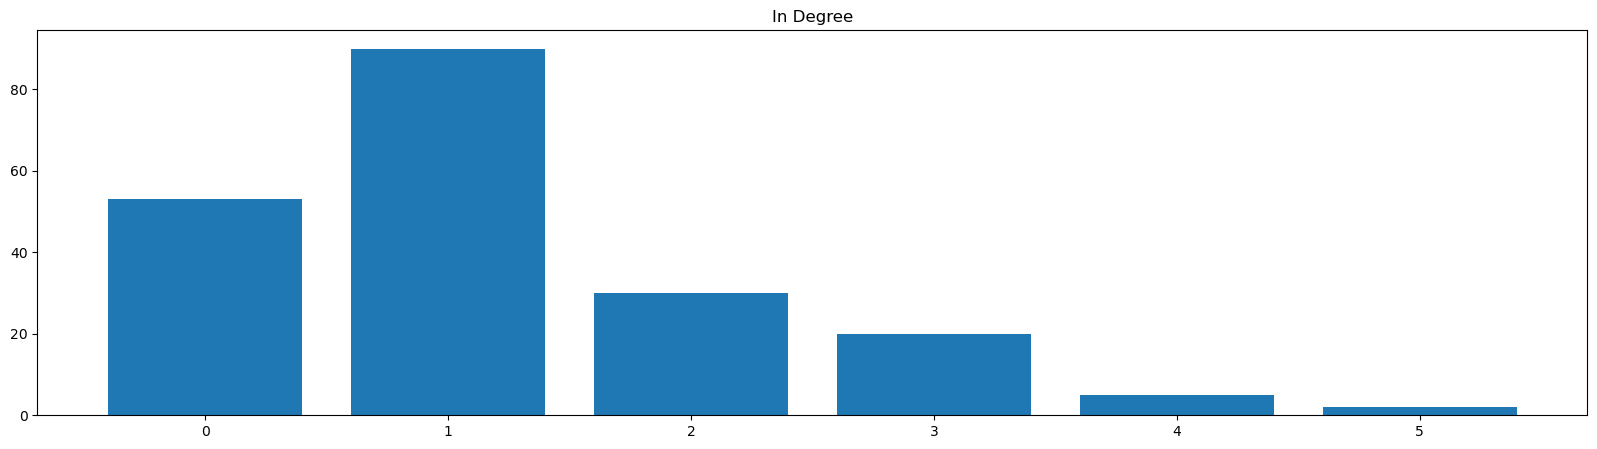

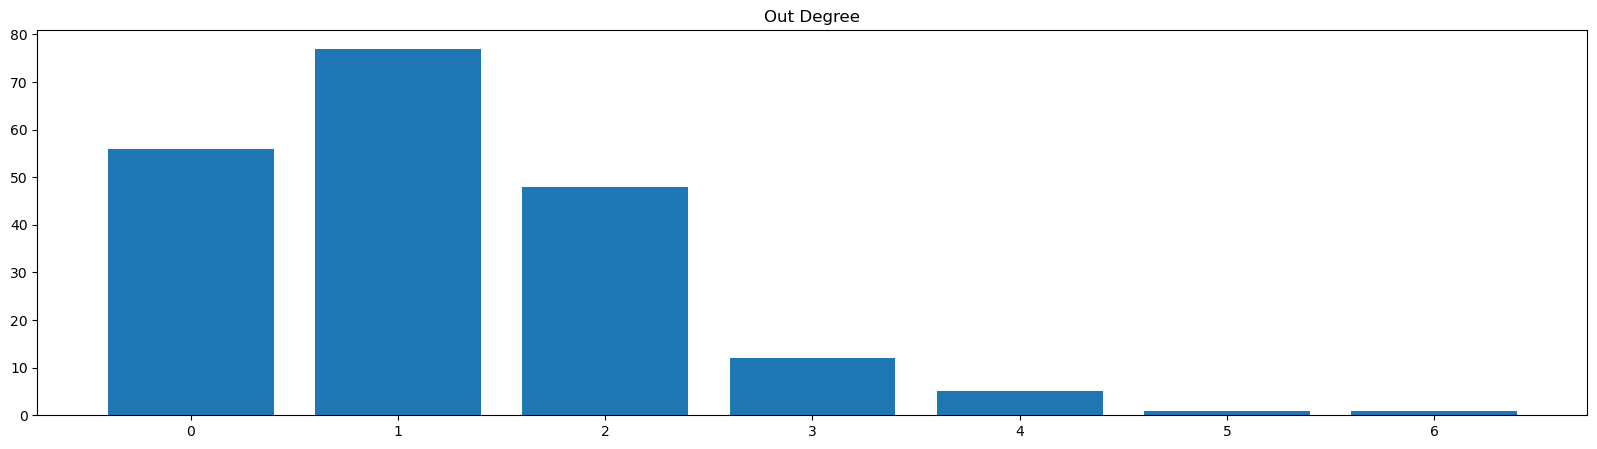

In [21]:
in_deg_sequence = list(dict(G.in_degree()).values())
out_deg_sequence = list(dict(G.out_degree()).values())
plt.bar(*np.unique(in_deg_sequence, return_counts=True))
plt.title("In Degree")
plt.show()

plt.bar(*np.unique(out_deg_sequence, return_counts=True))
plt.title("Out Degree")
plt.show()


### Getting Component Size Distribution

In [27]:
component_sizes = np.array([len(component) for component in nx.strongly_connected_components(G)])
print(component_sizes)
print(component_sizes.max())


[ 1  1  1  1  1  1  1  2  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1 10  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 10
  1  1  1  1  1  1  1  6  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]
10


### Get Fraction Driving
**Definition:** a node $u$ is defined to be driving another node $v$ $:=$ $u$ is not in the strongly connected component of $v$ but $(u,v) \in E$

In [6]:
def num_driving(G):
    C = nx.condensation(G)  # condensation collapeses a network into its scc and their connections (1 if there is any connection between them)
    node_to_scc = C.graph['mapping']
    drivers = [node_to_scc[u] != node_to_scc[v] for u, v in G.edges()]
    return sum(drivers)

def fraction_driving(G):
    return num_driving(G) / len(G.nodes())

print(fraction_driving(G))
print(num_driving(G))

0.045
9


In [7]:
def test_num_driving():
    # test function for the number driving with a barbell graph
    G = nx.barbell_graph(3, 1)
    G.add_edges_from([(7,8), (8,9), (9, 7)])
    G.remove_edges_from([(2,3), (3, 4)])
    G = nx.DiGraph(G)
    G.add_edges_from([(3, 2), (6, 3), (3, 7)])
    assert num_driving(G) == 3
    assert fraction_driving(G) == 3/10

test_num_driving()

### Reading and Writing using the file format


In [8]:
handler = file_io.HDF5FileHandler(file_path="test_file")

with handler:
    group_handler = handler.get_group_handler("test_group")
    group_handler.add_datasets(testdata = np.arange(10))
    group_handler.save_data()

try:
    handler2 = file_io.HDF5FileHandler(file_path="test_file")
    handler2.open_file(mode='r')
    group_handler = handler2.get_group_handler("test_group")
    group_handler.load_data()
    print(group_handler.datasets) 
finally:
    handler2.close_file()








{'testdata': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])}


In [ ]:
try:
    handler = file_io.HDf5FileHandler(file_path="")

finally:
    handler.close_file()